In [3]:
#Load libraries and split features/labels
import pandas as pd, numpy as np, json, time
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

train=pd.read_csv('../data/mitbih_train.csv',header=None)
test=pd.read_csv('../data/mitbih_test.csv',header=None)

X_train,y_train=train.iloc[:,:187].values,train[187].astype(int).values
X_test,y_test=test.iloc[:,:187].values,test[187].astype(int).values
print(X_train.shape,X_test.shape)

(87554, 187) (21892, 187)


In [5]:
#train both models
models={
    "DecisionTree":DecisionTreeClassifier(class_weight='balanced',random_state=42),
    "RandomForest":RandomForestClassifier(n_estimators=100,class_weight='balanced',n_jobs=-1,random_state=42)
}

preds={}
for name,model in models.items():
    t=time.time()
    model.fit(X_train,y_train)
    print(f"{name} trained in {time.time()-t:.0f}s")
    preds[name]=model.predict(X_test)

DecisionTree trained in 25s
RandomForest trained in 14s


In [10]:
#reports
target_names=["N","S","V","F","Q"]
for name,p in preds.items():
    print(f"-===-{name}-===-")
    print(classification_report(y_test,p,target_names=target_names,digits=3))

-===-DecisionTree-===-
              precision    recall  f1-score   support

           N      0.975     0.976     0.976     18118
           S      0.691     0.656     0.673       556
           V      0.860     0.857     0.859      1448
           F      0.575     0.593     0.584       162
           Q      0.936     0.938     0.937      1608

    accuracy                          0.955     21892
   macro avg      0.807     0.804     0.806     21892
weighted avg      0.954     0.955     0.954     21892

-===-RandomForest-===-
              precision    recall  f1-score   support

           N      0.983     0.992     0.988     18118
           S      0.860     0.732     0.791       556
           V      0.945     0.930     0.937      1448
           F      0.823     0.716     0.766       162
           Q      0.985     0.963     0.974      1608

    accuracy                          0.977     21892
   macro avg      0.919     0.867     0.891     21892
weighted avg      0.977     0.9

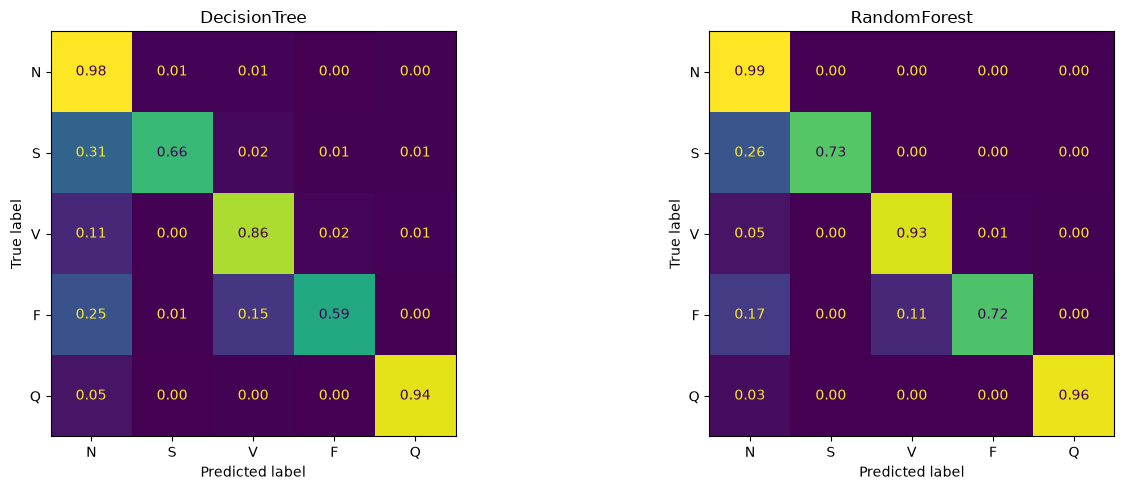

In [11]:
#confusion matrices
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,(name,p) in zip(axes,preds.items()):
    cm=confusion_matrix(y_test,p,normalize='true')
    ConfusionMatrixDisplay(cm,display_labels=target_names).plot(ax=ax,values_format='.2f',colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [ ]:
#Save results in a json file for later comparison 
results={name:{"accuracy":float((p==y_test).mean()),"macro_f1":float(f1_score(y_test,p,average='macro'))}
 for name,p in preds.items()
}
print(results)
with open('../data/baseline_results.json','w') as f:
    json.dump(results,f,indent=2)
with open('../results/baseline_results.json','w') as f:
    json.dump(results,f,indent=2)


{'DecisionTree': {'accuracy': 0.9545496071624338, 'macro_f1': 0.8056040432243691}, 'RandomForest': {'accuracy': 0.9772062854010597, 'macro_f1': 0.8911322050729386}}
